# Image Processing SoSe 2026 - Assignment - 02

### Deadline is 30.04.2026 at 11:55 a.m.

#### Students: Fabio Julius

Please solve the assignments together with a partner.

Make sure the code runs without errors, when clicking `Kernel` -> `Restart Kernel & Run All Cells`. Then save the notebook and upload your submission.

# Exercise 1 - 5 Points
Implement the `rgb_to_hsv` and `hsv_to_rgb` functions. Don't use any color conversion functions from a library.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def rgb_to_hsv(scrimg):

    image = np.copy(scrimg)

    for line in image:
        for row in line:
            r = row[0]
            g = row[1]
            b = row[2]

            MAX = max(r,g,b)
            MIN = min(r,g,b)

            if MAX == MIN:
                H = 0
            elif MAX == r:
                H = 60 * (0+ ((g-b)/(MAX-MIN)))
            elif MAX == g:
                H = 60 * (2+ ((b-r)/(MAX-MIN)))
            elif MAX == b:
                H = 60 * (4+ ((r-g)/(MAX-MIN)))

            if H < 0:
                H += 360

            if MAX == 0:
                S = 0
            else:
                S = (MAX-MIN)/MAX
            
            V = MAX

            row[0] = H
            row[1] = S
            row[2] = V

    return image

In [7]:
def hsv_to_rgb(scrimg):

    image = np.copy(scrimg)

    for line in image:
        for row in line:

            h = row[0]
            s = row[1]
            v = row[2]

            C = v * s
            X = C * (1- abs((h/60) % 2-1))
            M = v-C

            if 0 <= h <= 60:
                R, G, B = C, X, 0
            elif 60 <= h <= 120:
                R, G, B = X, C, 0
            elif 120 <= h <= 180:
                R, G, B = 0, C, X
            elif 180 <= h <= 240:
                R, G, B = 0, X, C
            elif 240 <= h <= 300:
                R, G, B = X, 0, C
            elif 300 <= h <= 360:
                R, G, B = C, 0, X

            R, G, B = (R+M)*255, (G+M)*255, (B+M)*255

            row[0] = R
            row[1] = G
            row[2] = B

    return image


Plot the saturation channel of the cat image

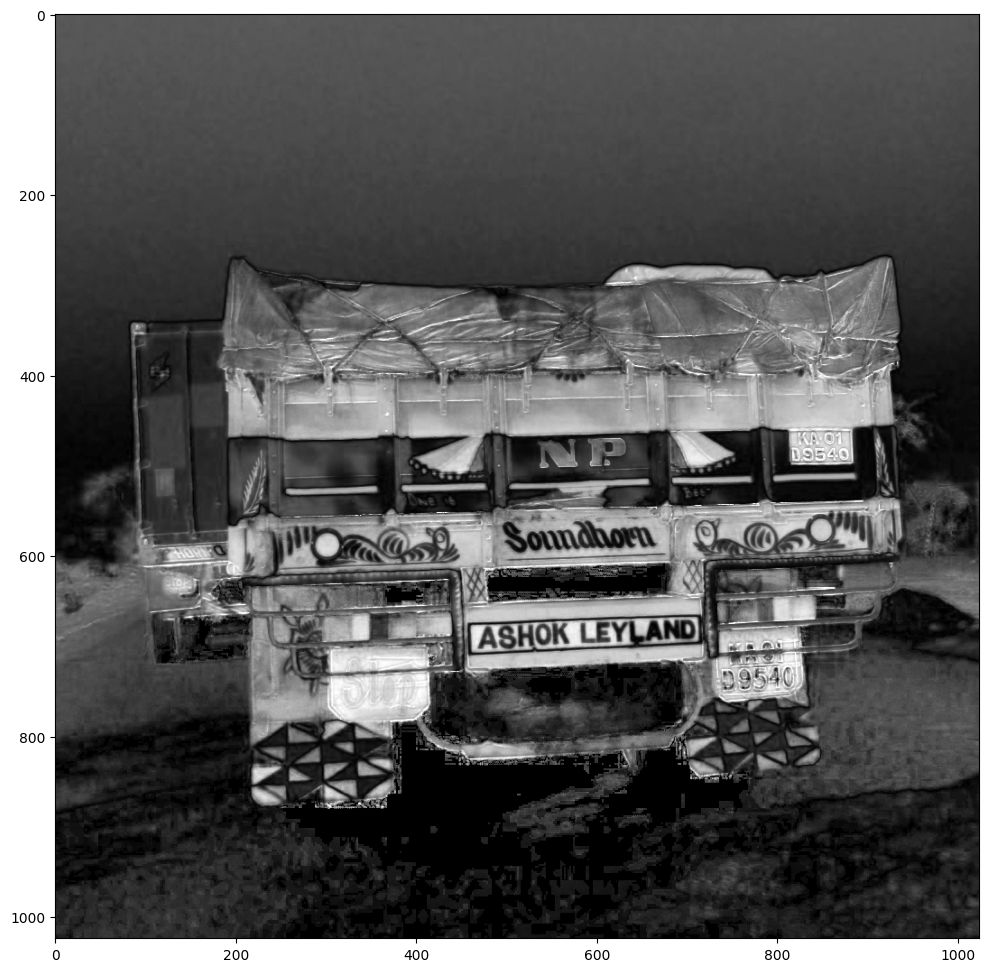

In [8]:
# display the plots inside the notebook
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pylab
pylab.rcParams['figure.figsize'] = (12, 12)   # This makes the plot bigger

img = mpimg.imread('imgs/02-truck.jpeg' , )
img = img / 255.

img_as_hsv = rgb_to_hsv(img)
plt.imshow(img_as_hsv[:,:,1], cmap='gray')
plt.show()

Increase the saturation by a factor of 2, convert it back to RGB and plot the result.

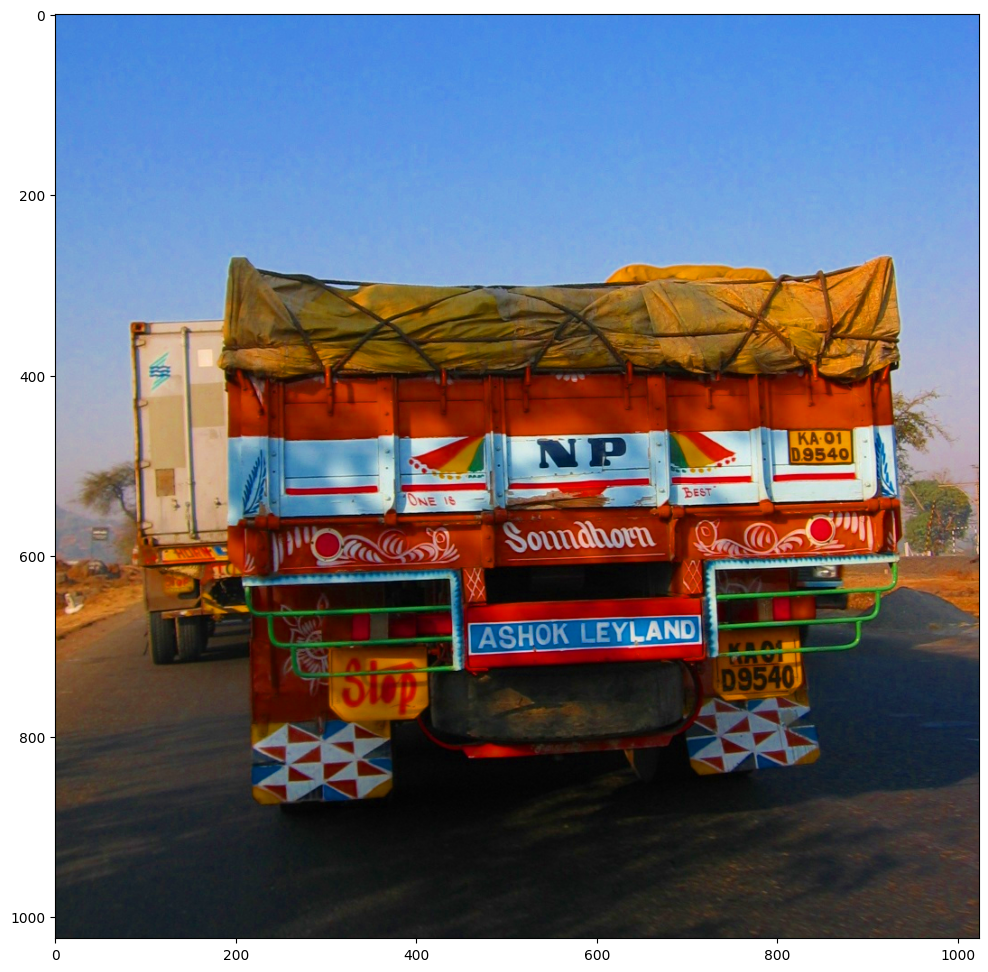

In [9]:
high_sat = np.copy(img_as_hsv)

for line in high_sat:
    for row in line:
        row[1] = min(1,row[1]*2)

high_sat = hsv_to_rgb(high_sat)
high_sat = high_sat / 255

plt.imshow(high_sat)
plt.show()

# Exercise 2 - 5 Points
Write a function to transform an RGB-image into the YUV color space, and another function to transform the image back (from YUV to RGB).

In [10]:
# we use the BT709 matrices here
# see https://en.wikipedia.org/wiki/YCbCr#ITU-R_BT.709_conversion
rgb_to_ycbcr = np.array([[0.2126, 0.7152, 0.0722],
                         [-0.1146, -0.3854, 0.5],
                         [0.5, -0.4542, -0.0458]])

def rgb_to_yuv(srcimg):
    image = np.copy(srcimg)

    for line in image:
        for row in line:

            Y = rgb_to_ycbcr[0][0] * row[0] + rgb_to_ycbcr[0][1] * row[1] + rgb_to_ycbcr[0][2] * row[2]
            Cb = rgb_to_ycbcr[1][0] * row[0] + rgb_to_ycbcr[1][1] * row[1] + rgb_to_ycbcr[1][2] * row[2]
            Cr = rgb_to_ycbcr[2][0] * row[0] + rgb_to_ycbcr[2][1] * row[1] + rgb_to_ycbcr[2][2] * row[2]
            
            row[0], row[1], row[2] = Y, Cb, Cr

    return image

Now do the following: Transform the image from the previous task into the YUV-color space. Write a function to perform a 4:2:0 chroma-subsampling, i.e. the chroma channels are for 4 pixels the same, and apply this function. Transform the resulting image back into the RGB-space

In [11]:
def chroma_subsampling(srcimg):
    image = np.copy(srcimg)
    height, width, _ = image.shape

    for i in range(0, height-1, 2):
        for k in range(0, width-1, 2):

            Cb = (image[i,k][1] + image[i,k+1][1] + image[i+1,k][1] + image[i+1,k+1][1]) / 4
            Cr = (image[i,k][2] + image[i,k+1][2] + image[i+1,k][2] + image[i+1,k+1][2]) / 4

            image[i,k][1] = Cb
            image[i,k+1][1] = Cb
            image[i+1,k][1] = Cb
            image[i+1,k+1][1] = Cb

            image[i,k][2] = Cr
            image[i,k+1][2] = Cr
            image[i+1,k][2] = Cr
            image[i+1,k+1][2] = Cr

    return image

ycbcr_to_rgb = np.array([[1, 0, 1.5748],
                         [1, -0.1873, -0.4681],
                         [1, 1.8556, 0]])

def yuv_to_rgb(srcimg):
    image = np.copy(srcimg)

    for line in image:
        for row in line:

            R = ycbcr_to_rgb[0][0] * row[0] + ycbcr_to_rgb[0][1] * row[1] + ycbcr_to_rgb[0][2] * row[2]
            G = ycbcr_to_rgb[1][0] * row[0] + ycbcr_to_rgb[1][1] * row[1] + ycbcr_to_rgb[1][2] * row[2]
            B = ycbcr_to_rgb[2][0] * row[0] + ycbcr_to_rgb[2][1] * row[1] + ycbcr_to_rgb[2][2] * row[2]

            row[0], row[1], row[2] = R, G, B
    
    return np.clip(image, 0, 1)

 Plot the original image and the 4:2:0 chroma-subsampled images. Do you see differences and if so, where?

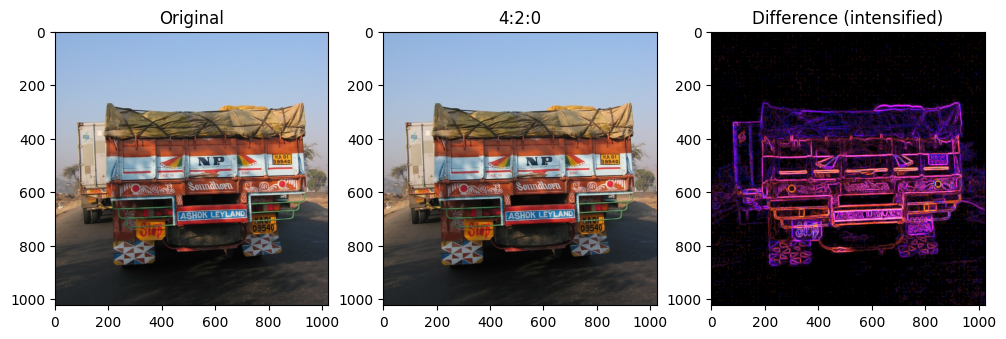

In [12]:
img_yuv = rgb_to_yuv(img)
img_yuv_420 = chroma_subsampling(img_yuv)
img_rgb = yuv_to_rgb(img_yuv_420)

diff = np.abs(img - img_rgb)

fig, axs = plt.subplots(1,3)
axs[0].imshow(img)
axs[0].set_title("Original")
axs[1].imshow(img_rgb)
axs[1].set_title("4:2:0")
axs[2].imshow(np.clip(diff * 50, 0, 1))
axs[2].set_title("Difference (intensified)")
plt.show()

#U don't see any difference unless u plot the difference and intensify it